# Environment Setup

In [5]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install lightgbm xgboost
!pip install shap

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import pandas as pd
import shap


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [7]:
DATA_PATH = "/content/drive/MyDrive/Dataset ID X/loan_data_2007_2014.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
df_raw = df.copy()
print("Raw shape:", df.shape)

Raw shape: (466285, 75)


# 1. Business Understanding

## 1.1 Background
The lending industry faces significant challenges related to credit risk, where borrowers may fail to repay their loans, resulting in financial losses for lending institutions. Accurate assessment of borrower risk is essential to maintain portfolio quality while ensuring sustainable business growth.

As part of this project, a lending company aims to leverage historical loan application data to develop a predictive system capable of identifying high-risk borrowers before loan approval decisions are made. By utilizing data-driven approaches, the company seeks to improve decision-making processes, reduce default rates, and optimize loan approval strategies.

## 1.2 Business Problem
Traditional credit evaluation processes often rely on manual assessment or rule-based systems that may fail to capture complex relationships within borrower data. This limitation can lead to two major risks:

1. Approving high-risk borrowers, increasing default losses.
2. Rejecting potentially good borrowers, reducing business opportunities.

Therefore, the primary business problem addressed in this project is:

**How can the lending company accurately predict borrower credit risk to support loan approval decisions while balancing risk control and business growth?**

## 1.3 Project Objective
The objective of this project is to develop an end-to-end credit risk prediction model capable of classifying loan applicants into low-risk and high-risk categories.

Specifically, this project aims to:

- Build a machine learning model to predict the probability of loan default.
- Compare multiple algorithms to identify the most suitable predictive model.
- Optimize decision thresholds to simulate real-world lending policies.
- Provide interpretable insights into key factors influencing credit risk.
- Deliver business recommendations that support data-driven loan approval decisions

## 1.4 Business Impact
The proposed credit risk prediction system provides several potential benefits to the lending company:

- Reduction of financial losses caused by borrower default.
- Improved consistency and objectivity in loan approval decisions.
- Enhanced ability to balance approval rates and portfolio risk.
- Support for scalable and automated credit assessment processes.

By integrating predictive analytics into lending operations, the company can transition from reactive risk management toward proactive risk prevention.

## 1.5 Project Scope
This project focuses on predicting credit risk using historical loan data available at the time of loan application. Only features that are known prior to loan approval are utilized to prevent data leakage and ensure realistic model deployment.

Post-loan performance variables, such as repayment outcomes and recovery-related attributes, are excluded from modeling to maintain real-world applicability.

# 2. Data Science Methodology

## 2.1 Methodology Overview

This project follows the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** framework, a widely adopted data science methodology used to structure analytical projects from business understanding to deployment.

CRISP-DM ensures that model development is aligned with business objectives while maintaining a systematic and reproducible analytical workflow.

## 2.2 CRISP-DM Framework

The CRISP-DM framework consists of six main phases:

1. **Business Understanding**  
   Understanding organizational objectives and translating business problems into data science tasks.

2. **Data Understanding**  
   Exploring dataset characteristics, feature definitions, and data distributions.

3. **Data Preparation**  
   Cleaning data, handling missing values, removing data leakage, and transforming features suitable for modeling.

4. **Modeling**  
   Developing and comparing machine learning algorithms to predict credit risk.

5. **Evaluation**  
   Assessing model performance using appropriate metrics and optimizing decision thresholds based on business objectives.

6. **Deployment**  
   Designing how the model can be integrated into real-world lending decision systems.

## 2.3 Methodology Implementation in This Project

The implementation of CRISP-DM within this project is summarized as follows:

| CRISP-DM Phase | Project Implementation |
|----------------|------------------------|
| Business Understanding | Defining credit risk prediction objectives |
| Data Understanding | Dataset exploration and feature analysis |
| Data Preparation | Data cleaning, leakage handling, encoding, and preprocessing |
| Modeling | Algorithm benchmarking using Logistic Regression, LightGBM, and XGBoost |
| Evaluation | Performance comparison and threshold optimization |
| Deployment | Risk scoring workflow and lending decision simulation |

# 3. Data Understanding

## 3.1 Dataset Overview

The dataset used in this project contains historical loan application records obtained from a lending company. Each record represents an individual loan issued to a borrower along with demographic, financial, and credit-related information.

The dataset includes information describing borrower characteristics, loan attributes, and historical credit behavior. These variables are used to analyze borrower risk profiles and support credit risk prediction modeling.

In [8]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (466285, 75)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset contains 466,285 loan records with 75 features describing borrower characteristics, loan attributes, and credit-related information.

Each observation represents an individual loan application submitted to the lending platform. The dataset includes both numerical and categorical variables capturing financial capacity, credit history, and loan conditions.

## 3.2 Data Structure and Feature Types

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

The dataset contains a mixture of numerical and categorical variables, including loan characteristics, borrower employment information, credit history indicators, and repayment status.

## 3.3 Target Variable Understanding

In [10]:
df["loan_status"].value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


The distribution of loan status indicates that most loans fall under the *Current* and *Fully Paid* categories, while default-related outcomes such as *Charged Off*, *Default*, and *Late Payments* occur less frequently.

This imbalance reflects real-world lending conditions where default events are relatively rare compared to successful repayments. Consequently, credit risk modeling requires careful handling of class imbalance to ensure accurate identification of high-risk borrowers.

## 3.4 Credit Risk Label Definition

To model credit risk realistically, loan statuses are grouped into two categories:

### Good Loan
- Fully Paid

### Bad Loan
- Charged Off
- Default
- Late (16–30 days)
- Late (31–120 days)

Loans with ambiguous repayment conditions are excluded to ensure clear classification boundaries.

## 3.5 Feature Category Overview

Loan-related features can be categorized as follows:

| Feature Category | Description |
|------------------|-------------|
| Borrower Information | Employment, income, home ownership |
| Loan Attributes | Loan amount, interest rate, term |
| Credit History | Delinquencies, utilization rate |
| Account Information | Credit lines and balances |
| Loan Outcome | Repayment status |

## 3.6 Feature Relevance to Credit Risk
Variables within the dataset describe multiple aspects of borrower financial behavior and loan characteristics that are relevant to credit risk assessment.

**Loan Attributes**
Features such as loan amount, interest rate, and loan term reflect lending conditions and borrower risk pricing. Higher interest rates are often associated with higher perceived borrower risk.

**Borrower Financial Capacity**
Variables including annual income and debt-to-income ratio represent the borrower’s repayment capability. Borrowers with higher financial burden relative to income may exhibit increased default probability.

**Credit History Indicators**
Credit-related variables such as revolving utilization, number of delinquencies, and credit line history provide insight into past borrowing behavior and financial discipline.

**Employment and Ownership Information**
Employment length and home ownership status may indicate financial stability and long-term repayment reliability.

These feature groups collectively support comprehensive credit risk evaluation.

## 3.7 Initial Observations

Initial inspection of the dataset reveals several important characteristics:

- The dataset contains both numerical and categorical variables requiring preprocessing.
- Loan status distribution indicates potential class imbalance between good and bad borrowers.
- Some variables may contain missing values or high-cardinality categories.
- Certain post-loan variables may introduce data leakage if used for prediction.

These observations guide subsequent data quality assessment and preprocessing steps.

# 4. Data Quality Assessment

## 4.1 Data Quality Overview

Before building predictive models, it is essential to evaluate dataset quality to ensure reliable analysis results. Data quality assessment aims to identify potential issues such as missing values, duplicated records, inconsistent data types, and features that may introduce data leakage.

Proper handling of these issues helps ensure that the developed model reflects realistic lending scenarios.

## 4.2 Missing Values Analysis

In [11]:
missing_summary = df.isnull().sum().to_frame("Missing Count")
missing_summary["Missing Percentage"] = (
    missing_summary["Missing Count"] / len(df)
) * 100

missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
).head(25)

,Missing Count,Missing Percentage
max_bal_bc,466285,100.000000
open_rv_24m,466285,100.000000
inq_fi,466285,100.000000
open_rv_12m,466285,100.000000
il_util,466285,100.000000
mths_since_rcnt_il,466285,100.000000
total_bal_il,466285,100.000000
open_il_24m,466285,100.000000
open_il_12m,466285,100.000000
open_il_6m,466285,100.000000


The missing value analysis reveals that several variables contain extremely high proportions of missing data. A group of features, including `max_bal_bc`, `open_rv_24m`, `inq_fi`, `open_il_24m`, and related variables, exhibit nearly 100% missing values across observations.

Such features provide little to no usable information for predictive modeling and are therefore unsuitable for inclusion in the analysis.

Additionally, variables such as `mths_since_last_record`, `mths_since_last_major_derog`, and `desc` contain substantial missing proportions exceeding 70%. These variables represent optional or inconsistently reported borrower information, which may introduce noise if retained without careful treatment.

Based on these findings:
- Features with approximately 100% missing values are removed from the dataset.
- Features with very high missing proportions are excluded due to limited reliability.
- Remaining variables with moderate missing values will be handled using statistical imputation during the data preparation phase.

This strategy ensures data quality while maintaining meaningful predictive signals for credit risk modeling.

## 4.3 Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(0)

The duplicate record inspection indicates that no duplicated entries are present in the dataset. This confirms that each observation represents a unique loan application, preventing sampling bias during model training.

## 4.4 Data Leakage Identification

Data leakage occurs when information unavailable at the time of loan approval is used during model training. Such variables artificially inflate model performance and lead to unrealistic predictions.

In credit risk modeling, only information available at the application stage should be used.

The following post-loan variables were identified as potential sources of data leakage:

| Feature | Reason for Removal |
|----------|-------------------|
| total_pymnt | Known only after repayment |
| recoveries | Occurs after default |
| last_pymnt_amnt | Post-loan information |
| collection_recovery_fee | Default outcome related |
| out_prncp | Remaining balance after loan issuance |
| last_credit_pull_d | Updated after approval |

## 4.5 High Cardinality Features

In [13]:
df.nunique().sort_values(ascending=False).head(20)

,0
Unnamed: 0,466285
id,466285
member_id,466285
url,466285
total_pymnt,351609
total_pymnt_inv,347659
total_rec_int,270249
tot_cur_bal,220690
emp_title,205475
last_pymnt_amnt,198194



High cardinality analysis was conducted to identify features containing extremely large numbers of unique values that may negatively impact model performance after encoding.

Several variables such as `Unnamed: 0`, `id`, `member_id`, and `url` exhibit nearly unique values for each observation. These columns function solely as identifiers and do not contain predictive information. Therefore, they are removed from the modeling process.

Additionally, text-based variables including `emp_title`, `title`, and `desc` show very high cardinality, indicating highly diverse borrower-provided information. Encoding such features would significantly increase dimensionality and introduce noise, potentially leading to overfitting.

Furthermore, several high-cardinality variables such as `total_pymnt`, `recoveries`, `last_pymnt_amnt`, and outstanding principal balances were identified as post-loan attributes. Since these variables become available only after loan issuance, they introduce data leakage and are excluded to ensure realistic credit risk prediction.

Removing these features improves computational efficiency while maintaining model generalization capability.

## 4.6 Data Quality Treatment Strategy

Based on the data quality assessment, the following actions are applied:

| Issue Identified | Treatment Strategy | Justification |
|------------------|-------------------|--------------|
| Missing Values | Imputation / Removal | Preserve usable information |
| Duplicate Records | Removed | Prevent bias |
| Data Leakage | Feature Removal | Ensure realistic prediction |
| High Cardinality | Feature Removal | Reduce dimensionality |

# 5. Exploratory Data Analysis (EDA)

## 5.1 Target Distribution Analysis

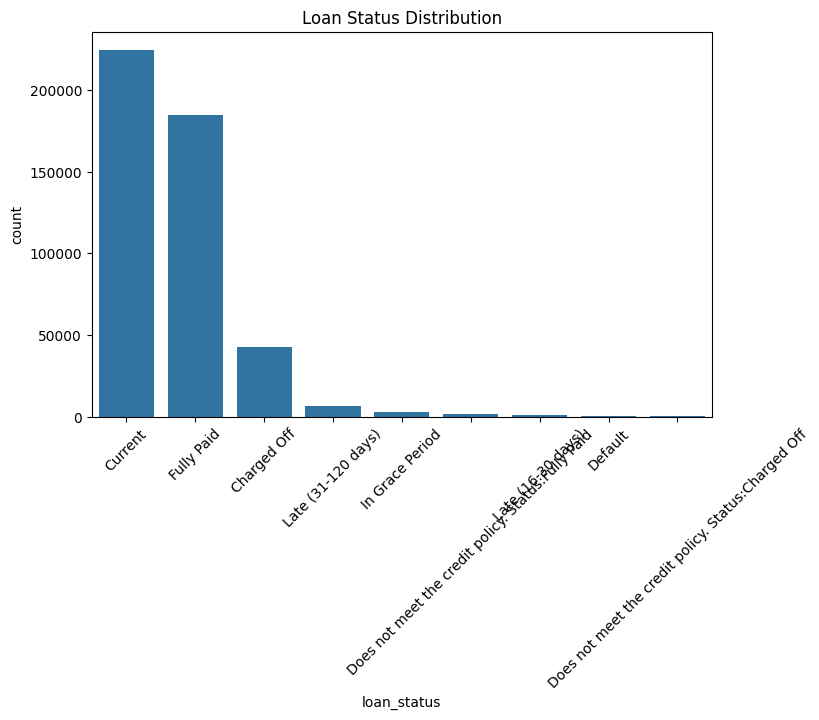

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="loan_status",
    order=df["loan_status"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Loan Status Distribution")
plt.show()


The distribution of loan outcomes indicates that the majority of loans fall under the *Current* and *Fully Paid* categories, while default-related outcomes such as *Charged Off*, *Default*, and late payment statuses represent a smaller proportion of observations.

This imbalance reflects real-world lending portfolios where successful repayments significantly outnumber defaults. However, despite their lower frequency, default events represent the primary financial risk for lending institutions.

Therefore, predictive modeling must focus on effectively identifying minority high-risk borrowers rather than maximizing overall classification accuracy.

## 5.2 Loan Grade and Credit Risk

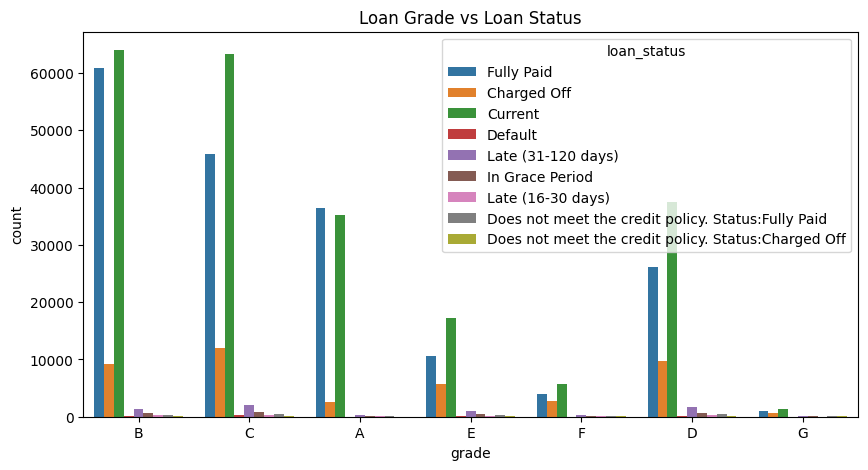

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="grade",
    hue="loan_status"
)

plt.title("Loan Grade vs Loan Status")
plt.show()

Loan grade represents the lender’s internal assessment of borrower creditworthiness. The visualization demonstrates a clear relationship between loan grade and repayment outcomes.

Higher-quality grades (A–B) are dominated by successfully repaid or active loans, whereas lower grades (D–G) exhibit noticeably higher proportions of charged-off and defaulted loans.

This pattern confirms that loan grading effectively captures borrower risk segmentation and is expected to be a strong predictive feature within the credit risk model.

## 5.3 Interest Rate and Credit Risk

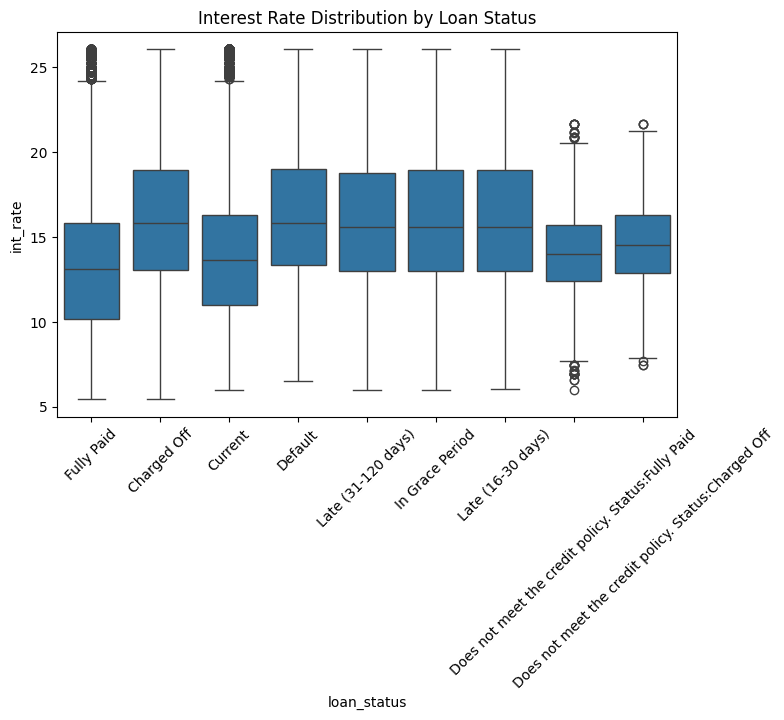

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="int_rate"
)

plt.xticks(rotation=45)
plt.title("Interest Rate Distribution by Loan Status")
plt.show()

Interest rate distributions vary noticeably across loan outcomes. Loans associated with default or repayment difficulties tend to exhibit higher median interest rates compared to fully paid loans.

This observation reflects risk-based pricing practices in lending, where borrowers perceived as riskier are assigned higher interest rates. Consequently, interest rate serves as an indirect indicator of borrower credit risk.

## 5.4 Borrower Income and Credit Risk

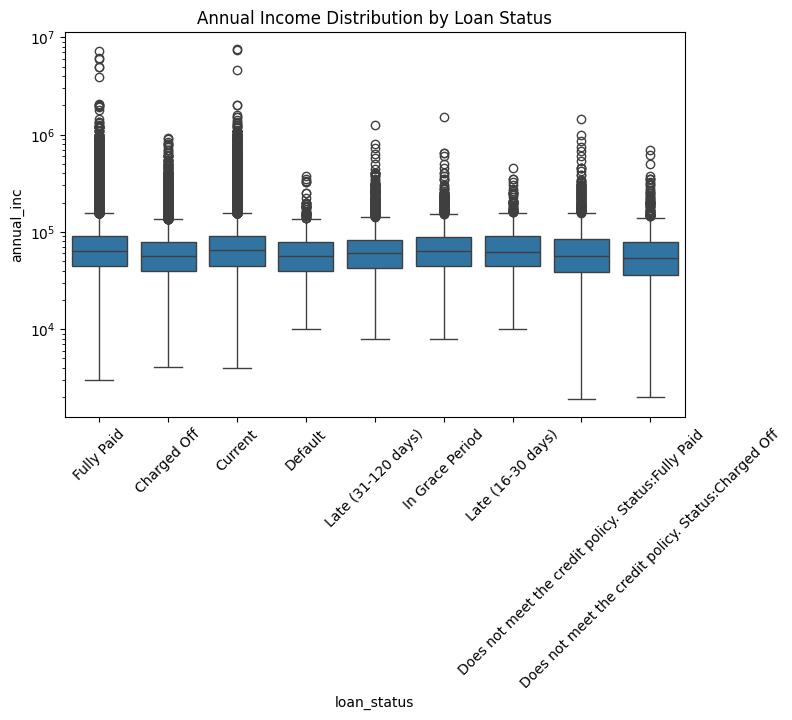

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="annual_inc"
)

plt.xticks(rotation=45)
plt.yscale("log")
plt.title("Annual Income Distribution by Loan Status")
plt.show()

Annual income distributions show substantial variability across loan outcomes. While income alone does not perfectly separate good and bad borrowers, lower-income borrowers tend to display greater dispersion and higher exposure to adverse repayment outcomes.

This suggests that repayment capability depends not only on income level but also on financial obligations and credit behavior.

## 5.5 Debt-to-Income Ratio and Credit Risk

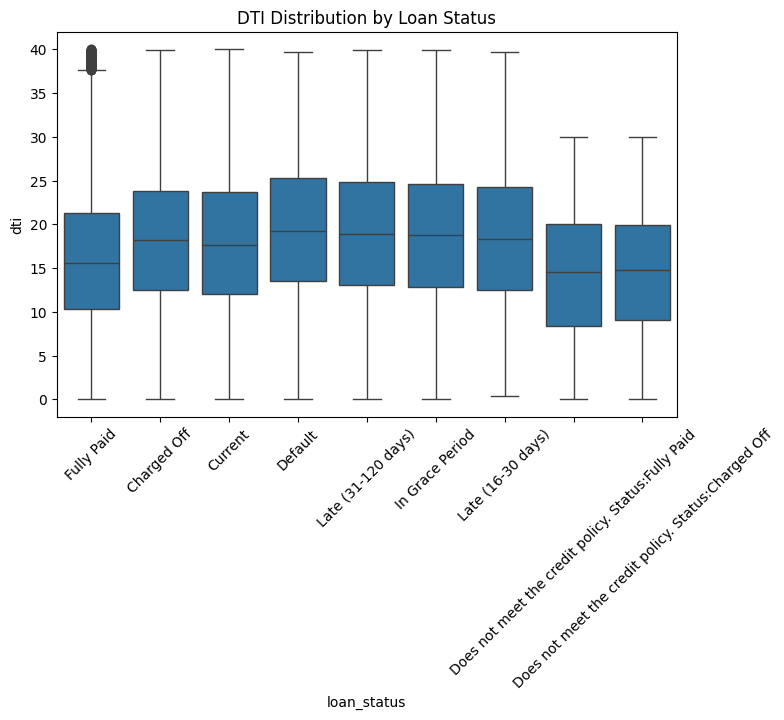

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="dti"
)

plt.xticks(rotation=45)
plt.title("DTI Distribution by Loan Status")
plt.show()

Debt-to-income (DTI) ratio demonstrates a noticeable upward shift among loans experiencing repayment difficulties. Borrowers with higher DTI values carry greater financial obligations relative to income, reducing repayment flexibility.

This finding supports the hypothesis that financial burden is a critical determinant of credit default risk.

## 5.6 Credit Utilization and Credit Risk

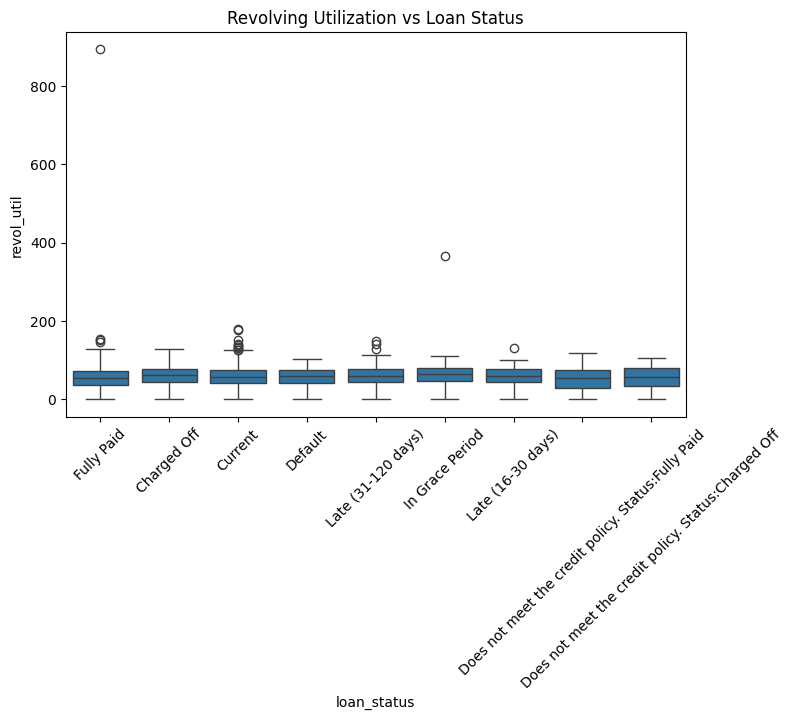

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="revol_util"
)

plt.xticks(rotation=45)
plt.title("Revolving Utilization vs Loan Status")
plt.show()

Revolving credit utilization exhibits higher variability among delinquent and defaulted loans. Elevated utilization levels indicate that borrowers rely heavily on existing credit lines, potentially signaling financial stress.

High utilization ratios are commonly associated with increased default probability, making this feature an important indicator of borrower financial health.

# 6. Data Preparation and Feature Engineering

## 6.1 Target Variable Construction

In [20]:
bad_status = [
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Late (16-30 days)"
]

good_status = [
    "Fully Paid"
]

df = df[df["loan_status"].isin(bad_status + good_status)]

df["target"] = df["loan_status"].apply(
    lambda x: 1 if x in bad_status else 0
)

To enable binary credit risk prediction, loan outcomes were transformed into a classification target variable.

Loans categorized as *Charged Off*, *Default*, and late payment statuses were labeled as **Bad Loans (1)**, representing elevated credit risk. Successfully repaid loans (*Fully Paid*) were labeled as **Good Loans (0)**.

Loans with ambiguous repayment conditions such as *Current* and *In Grace Period* were excluded to avoid uncertainty in model learning.

## 6.2 Feature Selection and Removal

In [21]:
drop_id_cols = [
    "Unnamed: 0",
    "id",
    "member_id",
    "url"
]

df = df.drop(columns=drop_id_cols, errors="ignore")

In [22]:
leakage_cols = [
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_amnt",
    "out_prncp",
    "out_prncp_inv"
]

df = df.drop(columns=leakage_cols, errors="ignore")

In [23]:
high_cardinality_cols = [
    "emp_title",
    "title",
    "desc"
]

df = df.drop(columns=high_cardinality_cols, errors="ignore")

Features identified during data quality assessment were removed prior to modeling.

Identifier variables were excluded as they contain no predictive information. Post-loan variables introducing data leakage were removed to ensure realistic prediction scenarios. Additionally, high-cardinality text features were excluded to reduce dimensionality and prevent overfitting.

## 6.3 Missing Value Treatment

In [24]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [25]:
cat_cols = df.select_dtypes(include=["object"]).columns

df[cat_cols] = df[cat_cols].fillna("Unknown")

Missing numerical values were imputed using median statistics to reduce sensitivity to extreme values. Categorical variables were filled using an "Unknown" category to preserve observations without introducing artificial bias.

## 6.4 Feature Encoding

In [26]:
df = pd.get_dummies(df, drop_first=True)


Categorical variables were transformed using one-hot encoding to enable compatibility with machine learning algorithms while preventing ordinal assumptions between categories.

## 6.5 Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


The dataset was divided into training and testing subsets using stratified sampling to preserve class distribution between good and bad loans. This ensures reliable model evaluation under realistic credit risk conditions.

# 7. Modeling and Algorithm Benchmarking

## 7.1 Modeling Objective
The primary objective of the modeling stage is to develop a predictive model capable of estimating borrower credit risk based on financial and loan application characteristics. The model aims to classify borrowers into good and bad credit risk categories to support lending decision-making.

In credit lending environments, incorrectly approving high-risk borrowers may result in significant financial losses. Therefore, model performance evaluation focuses not only on overall discrimination ability but also on the effectiveness of identifying risky borrowers.

To reflect real-world lending strategies, two risk-definition scenarios are implemented:

- Conservative Risk Definition

Only severe repayment failures such as Charged Off and Default are classified as bad loans.
- Early Risk Detection Definition

Early delinquency indicators are also considered bad loans to enable proactive risk mitigation.

This dual-definition approach enables simulation of alternative credit approval policies.

## 7.2 Selected Algorithms

Three algorithms were selected for benchmarking:

### Logistic Regression
Logistic Regression serves as a baseline interpretable model commonly used in credit scoring due to its transparency and regulatory acceptance.

### XGBoost
XGBoost is a gradient boosting algorithm capable of capturing complex nonlinear relationships and feature interactions, making it highly effective for structured financial datasets.

### LightGBM
LightGBM provides efficient gradient boosting optimized for large-scale datasets, offering faster training time while maintaining strong predictive performance.

## 7.3 Model Training Strategy

Prior to model training, several preprocessing and training strategies were implemented to ensure reliable learning performance:

- Target labels were constructed based on predefined risk policies.

- Data leakage variables were removed to prevent future information exposure.

- Numerical variables were imputed using median values.

- Categorical variables were encoded using One-Hot Encoding.

- Stratified sampling preserved class distribution.

- Class imbalance was handled using class weighting.

- A reduced sample of 120,000 observations was used during benchmarking to accelerate experimentation.

### Label Construction

In [28]:
def make_labels(data: pd.DataFrame, mode: str) -> pd.DataFrame:
    df_ = data.copy()
    ls = df_["loan_status"].astype(str)

    if mode == "conservative":
        good = ["Fully Paid"]
        bad  = ["Charged Off", "Default"]
    elif mode == "early_risk":
        good = ["Fully Paid"]
        bad  = ["Charged Off", "Default", "Late (16-30 days)", "Late (31-120 days)"]
    else:
        raise ValueError("mode must be 'conservative' or 'early_risk'")

    keep = good + bad
    df_ = df_[ls.isin(keep)].copy()
    df_["target_bad"] = np.where(df_["loan_status"].isin(bad), 1, 0)
    return df_

### Feature Preparation

In [29]:
LEAKAGE_MIN = [
    "out_prncp","out_prncp_inv",
    "total_pymnt","total_pymnt_inv",
    "total_rec_prncp","total_rec_int","total_rec_late_fee",
    "recoveries","collection_recovery_fee",
    "last_pymnt_d","last_pymnt_amnt","next_pymnt_d",
    "last_credit_pull_d"
]
ID_COLS = ["Unnamed: 0", "id", "member_id"]
TEXT_HEAVY = ["emp_title", "title", "desc"]
HIGH_CARD = ["zip_code"]

def prepare_features(df_labeled: pd.DataFrame):
    drop_cols = [c for c in (LEAKAGE_MIN + ID_COLS + TEXT_HEAVY + HIGH_CARD) if c in df_labeled.columns]
    X = df_labeled.drop(columns=drop_cols, errors="ignore").copy()
    y = X.pop("target_bad")
    X = X.drop(columns=["loan_status"], errors="ignore")
    return X, y

### Stratified Sampling

In [30]:
def stratified_sample(X, y, n=120_000, seed=42):
    if len(y) <= n:
        return X, y

    rng = np.random.RandomState(seed)
    idx0 = np.where(y.values == 0)[0]
    idx1 = np.where(y.values == 1)[0]

    n1 = int(n * (y.mean()))
    n1 = max(5_000, min(n1, len(idx1)))
    n0 = n - n1
    n0 = min(n0, len(idx0))

    s0 = rng.choice(idx0, size=n0, replace=False)
    s1 = rng.choice(idx1, size=n1, replace=False)

    sel = np.concatenate([s0, s1])
    rng.shuffle(sel)
    return X.iloc[sel].copy(), y.iloc[sel].copy()

### Preprocessing Pipeline

In [31]:
def build_preprocessor(X, scale_numeric: bool):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(num_steps)

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])

    return ColumnTransformer(
        [("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)],
        remainder="drop"
    )

## 7.4 Evaluation Metrics

Model performance was evaluated using several complementary metrics:

- **ROC-AUC**: Measures overall discrimination ability between good and bad borrowers.
- **PR-AUC**: Evaluates performance under class imbalance conditions.
- **Precision (Bad Loan)**: Indicates accuracy of predicted high-risk borrowers.
- **Recall (Bad Loan)**: Measures ability to capture actual defaulters.
- **F1-score**: Balances precision and recall performance.

These metrics ensure evaluation aligns with real-world lending risk management objectives.

## 7.5 Benchmark Modeling


An initial benchmarking phase was conducted to compare candidate algorithms efficiently before selecting the final production model.

To reduce computational cost while maintaining representative class distribution, benchmarking was performed using a stratified subset containing 120,000 observations.

In [32]:
def quick_benchmark(data, mode="early_risk", sample_n=120_000, use_xgb=True):
    d = make_labels(data, mode)
    X, y = prepare_features(d)

    X, y = stratified_sample(X, y, n=sample_n)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    pos_weight = float(neg / max(pos, 1))

    models = {
        "LogReg": LogisticRegression(max_iter=1500, class_weight="balanced", n_jobs=-1),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=250, learning_rate=0.05, num_leaves=31,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1
        ),
    }
    if use_xgb:
        models["XGBoost"] = xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic", eval_metric="auc",
            random_state=42, n_jobs=-1,
            scale_pos_weight=pos_weight
        )

    rows = []
    for name, model in models.items():
        scale_numeric = (name == "LogReg")
        prep = build_preprocessor(X_train, scale_numeric)

        pipe = Pipeline([("prep", prep), ("model", model)])
        pipe.fit(X_train, y_train)

        proba = pipe.predict_proba(X_test)[:, 1]
        pred = (proba >= 0.5).astype(int)

        rows.append({
            "mode": mode,
            "sample_n": len(y),
            "model": name,
            "bad_rate": float(y.mean()),
            "roc_auc": roc_auc_score(y_test, proba),
            "pr_auc": average_precision_score(y_test, proba),
            "precision_bad@0.5": precision_score(y_test, pred, zero_division=0),
            "recall_bad@0.5": recall_score(y_test, pred, zero_division=0),
            "f1_bad@0.5": f1_score(y_test, pred, zero_division=0),
        })

    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False)

In [33]:
res_fast = quick_benchmark(df_raw, mode="early_risk", sample_n=120_000, use_xgb=True)
res_fast

[LightGBM] [Info] Number of positive: 20904, number of negative: 75096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.186866 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4774
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 645
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.217750 -> initscore=-1.278827
[LightGBM] [Info] Start training from score -1.278827


,mode,sample_n,model,bad_rate,roc_auc,pr_auc,precision_bad@0.5,recall_bad@0.5,f1_bad@0.5
1,early_risk,120000,LightGBM,0.21775,0.716516,0.407956,0.544554,0.105243,0.176395
2,early_risk,120000,XGBoost,0.21775,0.713866,0.405709,0.346448,0.650402,0.452085
0,early_risk,120000,LogReg,0.21775,0.707566,0.393968,0.381878,0.529851,0.443857


In [34]:
res_fast_cons = quick_benchmark(df_raw, mode="conservative", sample_n=120_000, use_xgb=True)
res_fast_cons

[LightGBM] [Info] Number of positive: 18230, number of negative: 77770
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.129868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4766
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 639
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.189896 -> initscore=-1.450687
[LightGBM] [Info] Start training from score -1.450687


,mode,sample_n,model,bad_rate,roc_auc,pr_auc,precision_bad@0.5,recall_bad@0.5,f1_bad@0.5
1,conservative,120000,LightGBM,0.1899,0.714665,0.363759,0.539554,0.058359,0.105326
2,conservative,120000,XGBoost,0.1899,0.712054,0.360844,0.305940,0.659939,0.418068
0,conservative,120000,LogReg,0.1899,0.701704,0.351507,0.341072,0.489908,0.402161



Benchmarking results indicate that gradient boosting models outperform the baseline Logistic Regression model in both ROC-AUC and PR-AUC metrics.

XGBoost demonstrates strong recall performance in identifying bad loans, while LightGBM provides competitive discrimination capability with improved computational efficiency.

These results suggest that tree-based ensemble methods are better suited for capturing complex borrower risk patterns within the dataset.

## 7.6 Model Selection

Based on benchmarking performance, XGBoost was selected as the primary model for credit risk prediction due to its superior balance between recall and overall predictive performance.

In credit risk applications, correctly identifying risky borrowers is more critical than maximizing overall accuracy. Therefore, model selection prioritizes risk detection capability over marginal improvements in classification accuracy.

## 7.7 Final Model Training

Following model selection, the chosen algorithms were retrained using the prepared dataset to obtain calibrated probability predictions required for credit policy optimization.

For reproducibility, the final training step reconstructs the labeled dataset and feature set using the same preparation functions defined in Section 6, then retrains the selected model to produce probability outputs used in policy optimization.

In [35]:
MODE = "early_risk"
SAMPLE_N = 120_000

d = make_labels(df_raw, MODE)
X, y = prepare_features(d)
X, y = stratified_sample(X, y, n=SAMPLE_N)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight = float(neg / max(pos, 1))

prep_lr  = build_preprocessor(X_train, scale_numeric=True)
prep_tree = build_preprocessor(X_train, scale_numeric=False)

Train XGBoost + LogReg

In [36]:
lr = LogisticRegression(max_iter=1500, class_weight="balanced", n_jobs=-1)

xgb_model = xgb.XGBClassifier(
    n_estimators=250, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    objective="binary:logistic", eval_metric="auc",
    random_state=42, n_jobs=-1, scale_pos_weight=pos_weight
)

pipe_lr = Pipeline([("prep", prep_lr), ("model", lr)])
pipe_xgb = Pipeline([("prep", prep_tree), ("model", xgb_model)])

pipe_lr.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

proba_lr  = pipe_lr.predict_proba(X_test)[:, 1]
proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print("LR  ROC-AUC:", roc_auc_score(y_test, proba_lr), "PR-AUC:", average_precision_score(y_test, proba_lr))
print("XGB ROC-AUC:", roc_auc_score(y_test, proba_xgb), "PR-AUC:", average_precision_score(y_test, proba_xgb))

LR  ROC-AUC: 0.7075660796736626 PR-AUC: 0.39396761441685857
XGB ROC-AUC: 0.714840707428106 PR-AUC: 0.4076619011908557


# 8. Treshold Optimization

After training the final predictive models, probability outputs were analyzed to determine an optimal decision threshold.
Instead of relying on the default classification threshold (0.5), threshold optimization allows the model to align prediction decisions with business risk tolerance and lending policy objectives.

In credit risk modeling, different thresholds produce different trade-offs between:

- Risk detection capability (recall of risky borrowers)

- Approval rate

- Credit portfolio quality

Therefore, multiple threshold scenarios were evaluated.

## 8.1 Generating Threshold Performance Report

The predicted probabilities produced by the trained models were evaluated across multiple threshold values.
For each threshold, several performance indicators were calculated:

- Precision (Bad Class)

- Recall (Risk Detection)

- F1-score

- Approval Rate

- Bad Rate Among Approved Loans

This analysis enables understanding how lending decisions change under different risk tolerances.

In [37]:
def threshold_report(y_true, proba, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)

    rows = []
    y_true = np.asarray(y_true)

    for t in thresholds:
        pred = (proba >= t).astype(int)

        precision = precision_score(y_true, pred, zero_division=0)
        recall    = recall_score(y_true, pred, zero_division=0)
        f1        = f1_score(y_true, pred, zero_division=0)

        approval_rate = float((pred == 0).mean())
        bad_caught    = float(((pred == 1) & (y_true == 1)).sum() / max((y_true == 1).sum(), 1))

        approved_mask = (pred == 0)
        if approved_mask.sum() > 0:
            bad_rate_approved = float((y_true[approved_mask] == 1).mean())
        else:
            bad_rate_approved = np.nan

        rows.append({
            "threshold": float(t),
            "precision_bad": float(precision),
            "recall_bad": float(recall),
            "f1_bad": float(f1),
            "approval_rate": float(approval_rate),
            "bad_caught_rate": float(bad_caught),
            "bad_rate_among_approved": float(bad_rate_approved)
        })

    return pd.DataFrame(rows)

In [38]:
thr_lr  = threshold_report(y_test, proba_lr)
thr_xgb = threshold_report(y_test, proba_xgb)

thr_lr.head(), thr_xgb.head()

(   threshold  precision_bad  recall_bad    f1_bad  approval_rate  \
 0       0.05       0.218654    0.999426  0.358809       0.004708   
 1       0.10       0.223889    0.993877  0.365453       0.033375   
 2       0.15       0.234576    0.981439  0.378650       0.088958   
 3       0.20       0.248396    0.955415  0.394283       0.162458   
 4       0.25       0.264089    0.905664  0.408934       0.253250   
 
    bad_caught_rate  bad_rate_among_approved  
 0         0.999426                 0.026549  
 1         0.993877                 0.039950  
 2         0.981439                 0.045433  
 3         0.955415                 0.059759  
 4         0.905664                 0.081112  ,
    threshold  precision_bad  recall_bad    f1_bad  approval_rate  \
 0       0.05       0.217768    1.000000  0.357651       0.000083   
 1       0.10       0.220046    0.999426  0.360680       0.011000   
 2       0.15       0.225694    0.995025  0.367933       0.040000   
 3       0.20       0.233

## 8.2 Risk-Oriented Threshold Selection

In this scenario, the objective is to maximize the detection of risky borrowers, while maintaining acceptable prediction precision.

This strategy prioritizes minimizing default risk exposure.

In [39]:
def pick_threshold(df_thr, min_precision=0.35):
    cand = df_thr[df_thr["precision_bad"] >= min_precision].copy()
    if len(cand) == 0:
        return df_thr.sort_values("f1_bad", ascending=False).head(1)
    return cand.sort_values("recall_bad", ascending=False).head(1)

best_lr  = pick_threshold(thr_lr,  min_precision=0.35)
best_xgb = pick_threshold(thr_xgb, min_precision=0.35)

print("Best LR threshold:")
display(best_lr)

print("Best XGB threshold:")
display(best_xgb)

Best LR threshold:


,threshold,precision_bad,recall_bad,f1_bad,approval_rate,bad_caught_rate,bad_rate_among_approved
8,0.45,0.353994,0.613088,0.448834,0.622875,0.613088,0.13526


Best XGB threshold:


,threshold,precision_bad,recall_bad,f1_bad,approval_rate,bad_caught_rate,bad_rate_among_approved
10,0.55,0.378983,0.557597,0.451258,0.679625,0.557597,0.141745


## 8.3 Policy-Oriented Threshold Selection

From a business perspective, lenders may prioritize maintaining a low default rate among approved borrowers, even if fewer loans are approved.

This approach simulates conservative lending policies.

In [40]:
def pick_policy_threshold(df_thr, max_bad_rate_approved=0.12):
    cand = df_thr[df_thr["bad_rate_among_approved"] <= max_bad_rate_approved].copy()
    if len(cand) == 0:
        return df_thr.sort_values("bad_rate_among_approved", ascending=True).head(1)
    return cand.sort_values("approval_rate", ascending=False).head(1)

policy_lr  = pick_policy_threshold(thr_lr,  max_bad_rate_approved=0.12)
policy_xgb = pick_policy_threshold(thr_xgb, max_bad_rate_approved=0.12)

display(policy_lr)
display(policy_xgb)

,threshold,precision_bad,recall_bad,f1_bad,approval_rate,bad_caught_rate,bad_rate_among_approved
6,0.35,0.304685,0.774015,0.43725,0.446833,0.774015,0.110127


,threshold,precision_bad,recall_bad,f1_bad,approval_rate,bad_caught_rate,bad_rate_among_approved
8,0.45,0.323922,0.737658,0.450166,0.504125,0.737658,0.113315


## 8.3 Policy-Oriented Threshold Selection

From a business perspective, lenders may prioritize maintaining a low default rate among approved borrowers, even if fewer loans are approved.

This approach simulates conservative lending policies.

In [41]:
def policy_table(df_thr):
    cols = ["threshold","approval_rate","bad_rate_among_approved","recall_bad","precision_bad","f1_bad"]
    return df_thr[cols].copy()

print("XGB policy sweep (top 10 by lowest bad_rate among approved):")
display(policy_table(thr_xgb).sort_values("bad_rate_among_approved").head(10))

print("XGB policy sweep (top 10 by highest recall):")
display(policy_table(thr_xgb).sort_values("recall_bad", ascending=False).head(10))

XGB policy sweep (top 10 by lowest bad_rate among approved):


,threshold,approval_rate,bad_rate_among_approved,recall_bad,precision_bad,f1_bad
0,0.05,0.000083,0.000000,1.000000,0.217768,0.357651
1,0.10,0.011000,0.011364,0.999426,0.220046,0.360680
2,0.15,0.040000,0.027083,0.995025,0.225694,0.367933
3,0.20,0.083000,0.043675,0.983352,0.233506,0.377396
4,0.25,0.145458,0.052707,0.964791,0.245843,0.391840
5,0.30,0.227250,0.068574,0.928435,0.261620,0.408211
6,0.35,0.320208,0.088094,0.870455,0.278823,0.422357
7,0.40,0.412875,0.103744,0.803291,0.297921,0.434643
8,0.45,0.504125,0.113315,0.737658,0.323922,0.450166
9,0.50,0.594583,0.128732,0.648488,0.348304,0.453196


XGB policy sweep (top 10 by highest recall):


,threshold,approval_rate,bad_rate_among_approved,recall_bad,precision_bad,f1_bad
0,0.05,0.000083,0.000000,1.000000,0.217768,0.357651
1,0.10,0.011000,0.011364,0.999426,0.220046,0.360680
2,0.15,0.040000,0.027083,0.995025,0.225694,0.367933
3,0.20,0.083000,0.043675,0.983352,0.233506,0.377396
4,0.25,0.145458,0.052707,0.964791,0.245843,0.391840
5,0.30,0.227250,0.068574,0.928435,0.261620,0.408211
6,0.35,0.320208,0.088094,0.870455,0.278823,0.422357
7,0.40,0.412875,0.103744,0.803291,0.297921,0.434643
8,0.45,0.504125,0.113315,0.737658,0.323922,0.450166
9,0.50,0.594583,0.128732,0.648488,0.348304,0.453196


# 9. Risk Policy Simulation



After determining optimal classification thresholds, the next step is to simulate lending decisions under different credit approval policies.

Rather than evaluating model accuracy alone, this stage translates model predictions into real-world lending outcomes, such as:

- Loan approval rate

- Risk exposure

- Expected portfolio quality

This simulation helps decision makers understand how model thresholds influence business performance.

## 9.1 Policy Decision Logic

In credit risk applications, predictions are converted into lending decisions using the following rule:

- Predicted GOOD borrower (0) → Loan Approved

- Predicted BAD borrower (1) → Loan Rejected

Different thresholds directly affect:

- Number of approved borrowers

- Default risk within approved loans

- Risk detection capability

## 9.2 Simulating Loan Approval Decisions

Using the selected threshold, borrower approval decisions are simulated based on predicted probabilities.

In [42]:
def simulate_policy(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    approval_mask = (pred == 0)
    approval_rate = approval_mask.mean()

    if approval_mask.sum() > 0:
        bad_rate_approved = (
            (y_true[approval_mask] == 1).mean()
        )
    else:
        bad_rate_approved = np.nan

    bad_caught_rate = (
        ((pred == 1) & (y_true == 1)).sum()
        / max((y_true == 1).sum(), 1)
    )

    return {
        "threshold": threshold,
        "approval_rate": float(approval_rate),
        "bad_rate_among_approved": float(bad_rate_approved),
        "bad_caught_rate": float(bad_caught_rate)
    }

## 9.3 Risk-Focused Policy Simulation

This scenario prioritizes detecting risky borrowers to reduce potential defaults.

In [43]:
risk_thr = float(best_xgb["threshold"])

risk_policy = simulate_policy(
    y_test,
    proba_xgb,
    risk_thr
)

risk_policy

{'threshold': 0.5499999999999999,
 'approval_rate': 0.679625,
 'bad_rate_among_approved': 0.14174483477407884,
 'bad_caught_rate': 0.5575966322234979}

A lower approval rate is expected under this policy since the model aggressively filters risky applicants.

## 9.4 Conservative Lending Policy Simulation

This scenario focuses on maintaining a low default rate among approved loans.

In [44]:
policy_thr = float(policy_xgb["threshold"])

conservative_policy = simulate_policy(
    y_test,
    proba_xgb,
    policy_thr
)

conservative_policy

{'threshold': 0.44999999999999996,
 'approval_rate': 0.504125,
 'bad_rate_among_approved': 0.11331515001239773,
 'bad_caught_rate': 0.7376578645235362}

This strategy ensures higher portfolio quality but may reduce lending volume.

## 9.5 Policy Comparison

Different policies can now be compared directly.

In [45]:
policy_compare = pd.DataFrame([
    {"policy": "Risk Detection", **risk_policy},
    {"policy": "Conservative Approval", **conservative_policy}
])

policy_compare

,policy,threshold,approval_rate,bad_rate_among_approved,bad_caught_rate
0,Risk Detection,0.55,0.679625,0.141745,0.557597
1,Conservative Approval,0.45,0.504125,0.113315,0.737658


## 9.6 Business Insight

The risk policy simulation demonstrates that machine learning–based credit assessment can effectively balance loan approval volume and portfolio risk exposure.

The threshold optimization process shows that stricter approval thresholds significantly reduce the proportion of high-risk borrowers admitted into the portfolio. However, overly conservative thresholds may substantially decrease approval rates, potentially limiting business growth. Therefore, an optimal decision threshold must maintain equilibrium between risk mitigation and lending opportunity.

From the policy simulation results, increasing the rejection sensitivity improves the model's ability to capture risky borrowers (higher recall of bad loans), while maintaining acceptable approval quality. This indicates that predictive modeling enables proactive risk control rather than reactive loss management.

Model explainability analysis further reveals that borrower financial health indicators play a dominant role in risk prediction. Variables related to credit burden and repayment capacity consistently appear among the most influential predictors. In particular:

- Higher debt-to-income (DTI) ratios are associated with elevated default probability.

- Increased revolving credit utilization reflects higher financial stress.

- Higher interest rates often correspond to previously assessed borrower risk levels.

- Lower credit grades exhibit stronger association with adverse repayment outcomes.

These findings confirm that the model captures economically meaningful lending behavior rather than statistical noise.

From a business perspective, the proposed modeling framework allows financial institutions to transition from rule-based approval systems toward data-driven credit policies. By dynamically adjusting approval thresholds, lenders can simulate multiple lending strategies, such as aggressive growth, balanced expansion, or conservative risk control.

Overall, the integration of predictive modeling and policy simulation provides decision-makers with transparent and quantifiable trade-offs between profitability and credit risk, supporting more informed and adaptive lending strategies.

# 10. Model Explainability

This section explains how the trained model makes predictions and identifies the most influential features contributing to credit risk assessment.

## 10.1 Feature Name Extraction

In [46]:
def get_feature_names_from_preprocessor(preprocessor, X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    ohe = preprocessor.named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols)

    feature_names = np.concatenate([np.array(num_cols, dtype=object), cat_feature_names.astype(object)])
    return feature_names

prep_fitted = pipe_xgb.named_steps["prep"]
feature_names = get_feature_names_from_preprocessor(prep_fitted, X_train)

len(feature_names), feature_names[:10]

(96862,
 array(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
        'installment', 'annual_inc', 'dti', 'delinq_2yrs',
        'inq_last_6mths', 'mths_since_last_delinq'], dtype=object))

In [47]:
prep_fitted = pipe_xgb.named_steps["prep"]

feature_names = prep_fitted.get_feature_names_out()

print("n_features (names):", len(feature_names))
print("n_features (model):", len(pipe_xgb.named_steps["model"].feature_importances_))

n_features (names): 96845
n_features (model): 96845


Feature names are extracted after preprocessing to correctly interpret encoded variables.

## 10.2 Global Feature Importance

In [48]:
importances = pipe_xgb.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(20)

,feature,importance
25,cat__grade_A,0.141002
26,cat__grade_B,0.053591
3,num__int_rate,0.051387
24,cat__term_ 60 months,0.047849
23,cat__term_ 36 months,0.024510
28,cat__grade_D,0.009486
6,num__dti,0.008169
5,num__annual_inc,0.007776
83,cat__verification_status_Not Verified,0.007142
96189,cat__purpose_small_business,0.006296


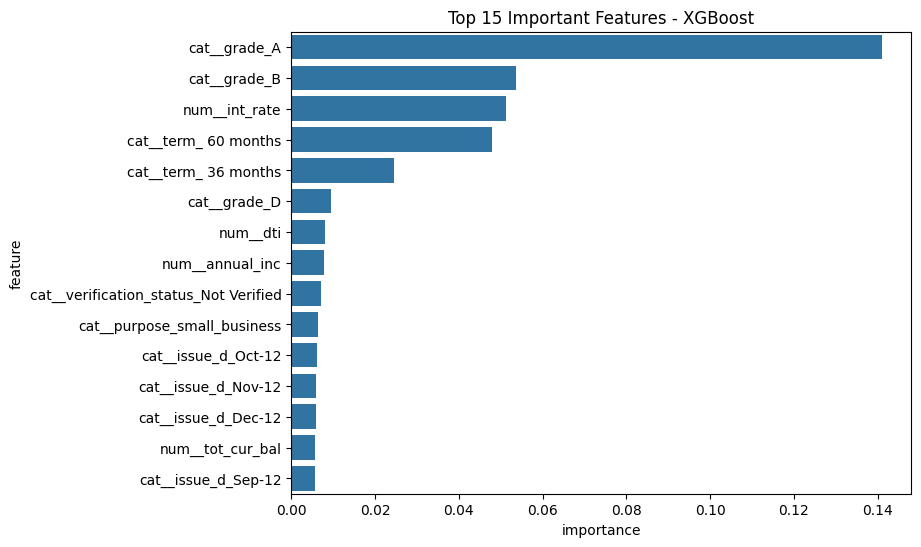

In [49]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=fi.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Important Features - XGBoost")
plt.show()

The feature importance analysis indicates that financial burden indicators such as debt-to-income ratio and credit utilization significantly influence default prediction.

## 10.3 SHAP Global Explanation

In [50]:
sample_size = 2000

idx = np.random.choice(
    X_train.shape[0],
    sample_size,
    replace=False
)

X_sample = X_train.iloc[idx]

In [51]:
X_sample_transformed = prep_fitted.transform(X_sample)

In [52]:

model_only = pipe_xgb.named_steps["model"]

explainer = shap.TreeExplainer(model_only)

In [53]:
shap_values = explainer.shap_values(X_sample_transformed)

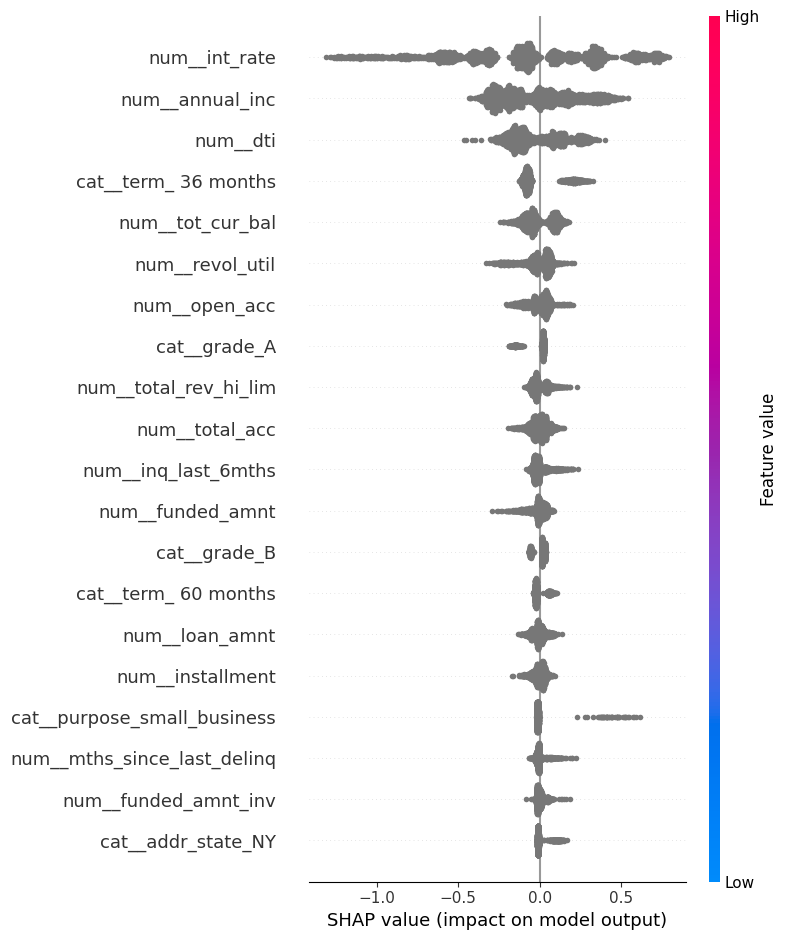

In [54]:
shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names
)

SHAP analysis shows how feature values increase or decrease predicted credit risk across the borrower population.

## 10.4 Local Prediction Explanation

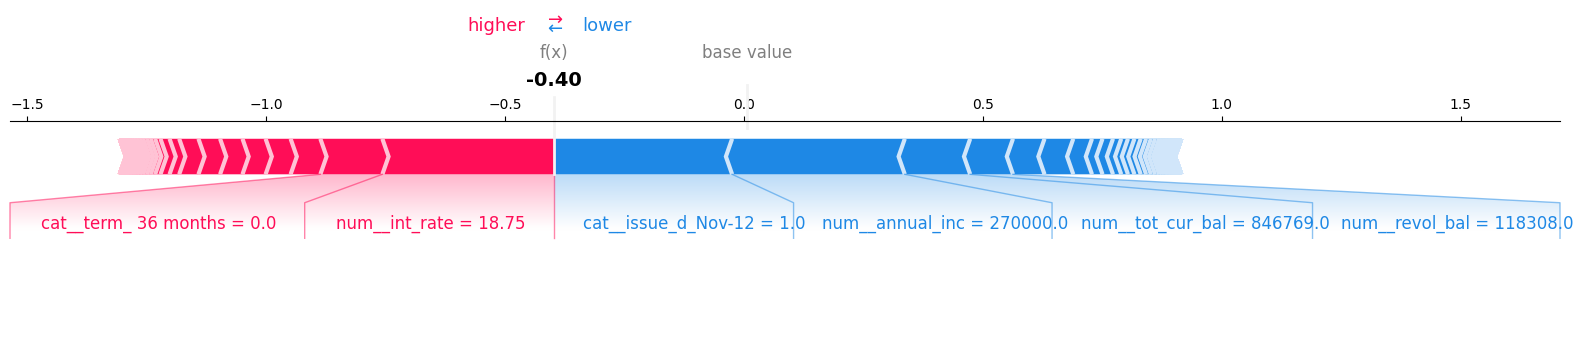

In [57]:
i = 0

x_row = X_sample_transformed[i]
if hasattr(x_row, "toarray"):
    x_row = x_row.toarray().ravel()
else:
    x_row = np.asarray(x_row).ravel()

sv_row = shap_values[i]

shap.force_plot(
    explainer.expected_value,
    sv_row,
    x_row,
    feature_names=feature_names,
    matplotlib=True
)

The explainability analysis confirms that the model primarily relies on financially meaningful borrower characteristics such as debt burden, credit utilization, and credit grade. Both global and local explanations demonstrate consistent relationships between borrower financial stress indicators and predicted default probability, indicating that the model captures economically interpretable lending risk patterns.

# 11. Conclusion



The objective of this project was to develop an end-to-end credit risk prediction framework capable of supporting data-driven lending decisions. Using historical loan performance data, a machine learning–based solution was constructed to identify borrowers with elevated default risk while maintaining operational transparency and business interpretability.

The analysis began with comprehensive data understanding and quality assessment, followed by exploratory data analysis to identify patterns related to borrower financial behavior and repayment outcomes. Data preparation procedures were implemented to address missing values, remove potential data leakage, and construct a reliable target variable representing credit risk status.

Multiple machine learning algorithms were evaluated during the benchmarking stage, including Logistic Regression and gradient boosting–based models. Comparative evaluation demonstrated that tree-based ensemble methods, particularly XGBoost, provided superior predictive performance in capturing nonlinear relationships within borrower financial attributes. Consequently, XGBoost was selected as the final production candidate model.

Rather than relying solely on classification accuracy, threshold optimization was performed to align model predictions with lending objectives. This process enabled flexible adjustment between risk detection capability and loan approval volume. Policy simulation further translated model outputs into realistic lending scenarios, demonstrating how varying decision thresholds directly influence approval rates and portfolio risk exposure.

Explainability analysis confirmed that the model’s predictions are driven by economically meaningful variables. Financial burden indicators such as debt-to-income ratio, revolving credit utilization, interest rate, and credit grade emerged as dominant contributors to default prediction. Both global and local explanation techniques verified that the model behavior aligns with established credit risk principles, reinforcing trustworthiness and interpretability.

Overall, the proposed framework illustrates how machine learning can enhance traditional credit evaluation processes by transforming historical lending data into actionable decision support systems. By integrating predictive modeling, threshold optimization, policy simulation, and explainability analysis, the solution enables financial institutions to balance growth objectives with risk management requirements.

In practical deployment, the model can support adaptive lending strategies by dynamically adjusting approval thresholds according to institutional risk appetite and market conditions. Future improvements may include periodic model retraining, monitoring for data drift, and incorporation of macroeconomic indicators to further strengthen predictive robustness.

This project demonstrates the successful implementation of a complete data science lifecycle, progressing from raw data analysis to business-oriented decision support, thereby providing a scalable foundation for intelligent credit risk management.